In [1]:
import pandas as pd ## dataframes
import numpy as np ## Mathematical operations
import matplotlib.pyplot as plt ## Representation
from matplotlib import rcParams
from matplotlib import colors
import random as random
import networkx as nx ## Network tools

In [2]:
def structural_characterization (filename):
    #read the file
    path = "activityA1/" + filename
    G_net = nx.read_pajek(path)
    G_net = nx.Graph(G_net)
    print(f'Structural characterization of '+ filename +' network:')

    #primary characteristics
    print('Number of nodes:', G_net.number_of_nodes())
    print('Number of edges:', G_net.number_of_edges())

    #degree
    degrees = [d for _, d in G_net.degree()]

    min_degree = min(degrees)
    max_degree = max(degrees)
    avg_degree = sum(degrees) / len(degrees)

    print(f"Minimum Degree: {min_degree}")
    print(f"Maximum Degree: {max_degree}")
    print(f"Average Degree: {avg_degree:.2f}")

    #clustering
    avg_clustering = nx.average_clustering(G_net)
    print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

    r = nx.degree_assortativity_coefficient(G_net)
    print(f"Assortativity Coefficient (r): {r:.4f}")

    #paths characteristics
    if nx.is_connected(G_net):
        avg_path = nx.average_shortest_path_length(G_net)
        d = nx.diameter(G_net)
    else:
        largest_cc = max(nx.connected_components(G_net), key=len)
        G_lcc = G_net.subgraph(largest_cc)

        avg_path = nx.average_shortest_path_length(G_lcc)
        d = nx.diameter(G_lcc)

        print("Graph is not connected, using largest connected component")

    print(f"Average Shortest Path Length: {avg_path:.2f}")
    print(f"Diameter: {d}")

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return G_net

# Characterize their macroscopic structure net1, net2, net3 and net4

In [3]:
G_net1 = structural_characterization("net1.net")
G_net2 = structural_characterization("net2.net")
G_net3 = structural_characterization("net3.net")
G_net4 = structural_characterization("net4.net")

Structural characterization of net1.net network:
Number of nodes: 5000
Number of edges: 25000
Minimum Degree: 6
Maximum Degree: 16
Average Degree: 10.00
Average Clustering Coefficient: 0.4141
Assortativity Coefficient (r): -0.0097
Average Shortest Path Length: 5.12
Diameter: 8
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Structural characterization of net2.net network:
Number of nodes: 5000
Number of edges: 24873
Minimum Degree: 1
Maximum Degree: 24
Average Degree: 9.95
Average Clustering Coefficient: 0.0021
Assortativity Coefficient (r): -0.0057
Average Shortest Path Length: 3.96
Diameter: 7
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Structural characterization of net3.net network:
Number of nodes: 5000
Number of edges: 23508
Minimum Degree: 3
Maximum Degree: 732
Average Degree: 9.40
Average Clustering Coefficient: 0.0862
Assortativity Coefficient (r): -0.1339
Average Shortest Path Length: 3.01
Diameter: 5
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [17]:
from collections import Counter

def degree_distribution(G):
    fig, ax = plt.subplots(figsize=(5, 3))
    
    degree_sequence = [G.degree(node) for node in G.nodes()]
    num_nodes = len(G.nodes())
    
    degree_counts = Counter(degree_sequence)
    min_degree = min(degree_sequence)
    max_degree = max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_probs = [degree_counts.get(x, 0) / num_nodes for x in degrees]

    ax.scatter(degrees, degree_probs, label='data')

    ax.set_xlabel('$k$', fontsize=15)
    ax.set_ylabel('$P(k)$', fontsize=15)
    ax.tick_params(which='major', axis='both', labelsize=15)
    ax.set_title('Degree Distribution (Linear Scale)', fontsize=15)
    
    fig.tight_layout()
    plt.show()


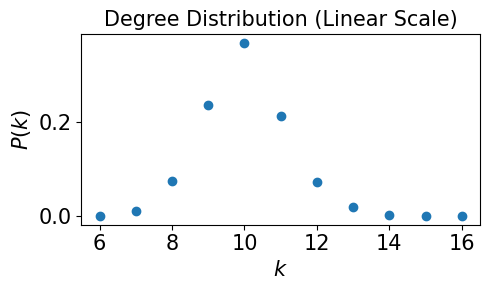

In [18]:
degree_distribution(G_net1)

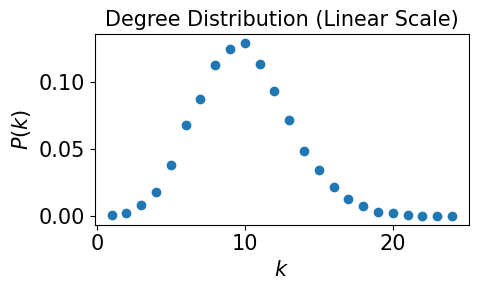

In [19]:
degree_distribution(G_net2)

In [46]:
def plot_log_binning(G, num_bins=10):
    degree_sequence = [G.degree(n) for n in G.nodes() if G.degree(n) > 0]
    num_nodes = len(G.nodes())
    
    min_deg, max_deg = min(degree_sequence), max(degree_sequence)
    bins = np.logspace(np.log10(min_deg), np.log10(max_deg), num_bins + 1)
    
    counts, bin_edges = np.histogram(degree_sequence, bins=bins)
    
    # Normalize
    bin_widths = np.diff(bin_edges)
    density = counts / (num_nodes * bin_widths)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    idx = density > 0
    log_k = np.log10(bin_centers[idx])
    log_P = np.log10(density[idx])
    
    m, b = np.polyfit(log_k, log_P, 1)
    
    theoretical_P = 10**(m * np.log10(bin_centers) + b)
    
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.scatter(bin_centers, density)

    ax.plot(bin_centers, theoretical_P, 'k-', label=f'$\\gamma = {-m:.2f}$')
    
    # Set both axes to log scale
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_xlabel('$k$', fontsize=15)
    ax.set_ylabel('$P(k)$', fontsize=15)
    ax.set_title('Degree Distribution (Log Binning)', fontsize=15)
    ax.legend()

    fig.tight_layout()
    plt.show()

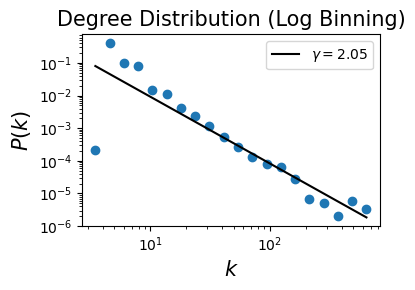

In [55]:
plot_log_binning(G_net3, num_bins=20)

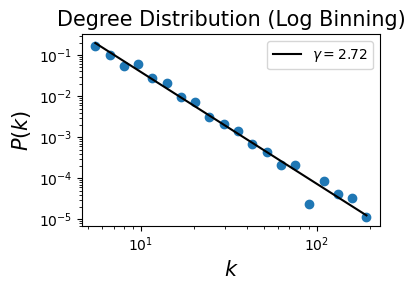

In [56]:
plot_log_binning(G_net4, num_bins=20)

In [ ]:
eigenvector_centralities=nx.eigenvector_centrality(G_net1)
betweenness_centralities=nx.betweenness_centrality(G)

eigenvector_centralities

{'0': 0.013194391044919698,
 '1': 0.011766927368960331,
 '2': 0.014855897002576198,
 '3': 0.014275153097257225,
 '4': 0.012357508922398513,
 '5': 0.012158717765624973,
 '6': 0.015380997421534802,
 '7': 0.014865588858552502,
 '8': 0.013424015149663623,
 '9': 0.015151012580226643,
 '10': 0.013116109820300936,
 '11': 0.01161701907046134,
 '12': 0.01436485342982234,
 '13': 0.0131619075049229,
 '14': 0.011596913787111111,
 '15': 0.010814789995639219,
 '16': 0.015151230930681919,
 '17': 0.015156424992202985,
 '18': 0.01354731431922786,
 '19': 0.014507597577145313,
 '20': 0.010067466537960715,
 '21': 0.013839835390743878,
 '22': 0.015114392150756856,
 '23': 0.015615026373282664,
 '24': 0.012674544819620532,
 '25': 0.015549641891153565,
 '26': 0.01345818770357397,
 '27': 0.014683686644716868,
 '28': 0.014537789931985722,
 '29': 0.014954956158027591,
 '30': 0.01503961515937613,
 '31': 0.017623527399369062,
 '32': 0.014861959952701759,
 '33': 0.01216867638317517,
 '34': 0.016762778309722514,
 '3